In [1]:
# You work at a fictional company called Machine Learning Housing Corporation, and your job is to build a model 
# that can predict housing prices in California.

# Questions to ask or look at
# What data do you have?  population, median income, and median housing price for each block group in California etc.
# Frame the Problem: How does the company expect to use and benefit from this model?
# the model prediction will be fed to another ml system to predict investment. So accuracy matters, bad predictions mean bad investments.
# What is the current solution? manual estimation by experts using partial data and complex rules with 30% off estimates.
# meaning its slow and expensive ml can improve on this. Estimates is off by 30% ml have to beat that. Ml is used for investment decision.

# Answers
# Its a supervised problem because data are labelled, its a regression problem since price is to be predicted.
# its a multiple regression problem since we have many features to make a prediction. its a univariate since we are trying to predict 
# one value for a district and there is no continius flow of data so no need to change or adapt to new data and data is small enough.

In [2]:
# Firstly we need to understand the features provided to us 

# longitude measuring how far west or east a district is located in California. Lower values (around −124) are closer to the Pacific Ocean.
# latitude measuring how far north or south the district is. Higher values (around 38–40) are farther north.
# housing_median_age older houses have higher values. It gives an idea of neighborhood maturity.
# total_rooms The total number of rooms in all houses within the district
# total_bedrooms The total number of bedrooms in all houses within the district.
# population The total number of people living in the district.
# households The total number of groups of people sharing a home)
# median_income The median income of households in the district, measured in tens of thousands of dollars.
# median_house_value The median value of houses in the district, this is your target variable (what you’ll predict)
# ocean_proximity Describes how close the district is to the ocean.


# The steps to solve the problem include 

# Load data, → Inspect missing values, → Explore distributions, skewness, outliers, → Identify important features, → Create stratification category
# Stratify train/test, → Drop stratification column, → Making more useful categories, → Seperate Target from label,
# → Build pipeline (impute, scale, encode), → visualise to check difference, → Train models, → Evaluate, → Tune, → Final model.

In [3]:
# importing the basic libaries we need 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# loading the data

from pathlib import Path

# a function for loading the data
def load_housing(local_path:None):
    url =  "https://raw.githubusercontent.com/ageron/data/main/housing/housing.csv"
    if local_path is not None and Path(local_path).is_file():
        return pd.read_csv(local_path)
    return pd.read_csv(url)

housing = load_housing(r"C:\Users\HP\Downloads\housing.csv") # path on my computer

In [9]:
print(housing.info())
print()
print(housing.isnull().sum()) # column total_bedrooms has 207 empty values
print()
print(housing.describe())

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB
None

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0


In [11]:
#  ocean_proximity is the only string so lets check the content out

print(housing['ocean_proximity'].value_counts())
print()
print(housing.dtypes.value_counts()) # to check different data types we have

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

float64    9
str        1
Name: count, dtype: int64


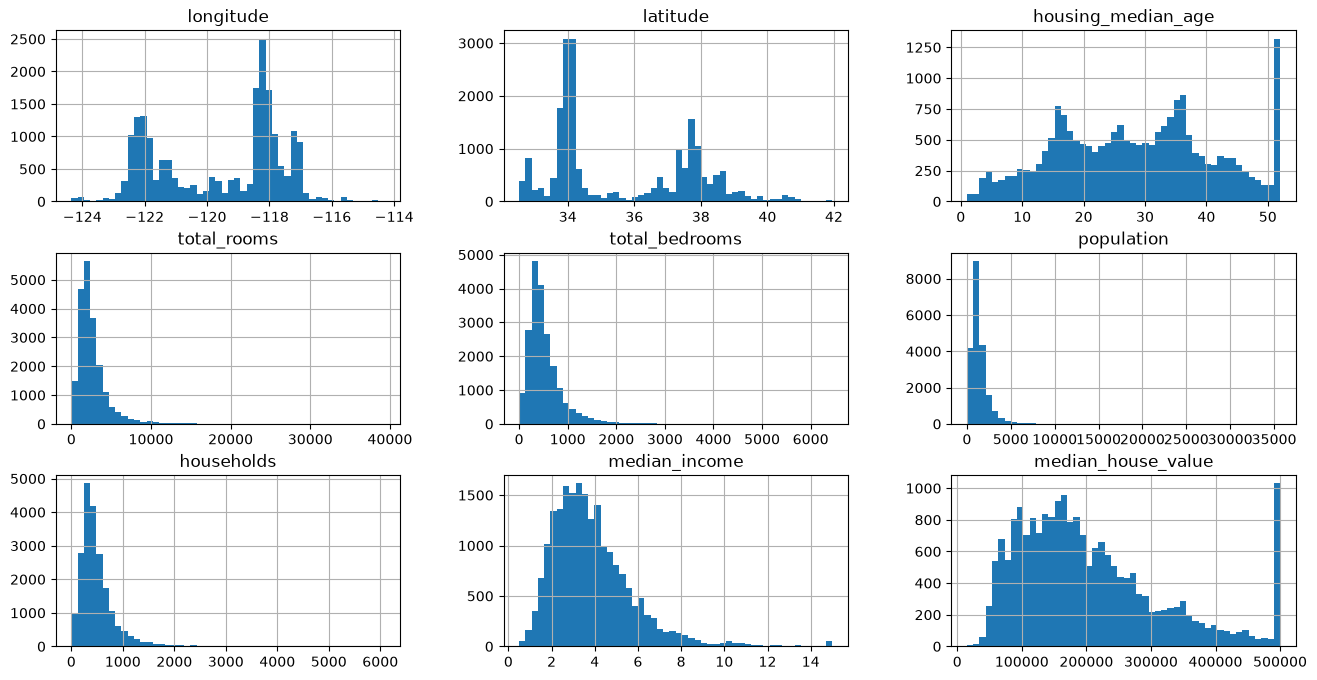

In [14]:
# lets explore with the use of histogram since we are dealing with numbers

housing.hist(bins=50, figsize=(16, 8))
plt.show()

# based on this diagam we can notice there is a right skewness as plot extend from left to right on total_rooms, total_bedrooms, 
# population, households. Which means we mostly have small values but we have few big values which can affect our model.

In [15]:
# lets check for skewness 

print(housing.skew(numeric_only=True))

# we can see the plot we have an extra moderate skewness on median income which we didn't pay attention on from histogram
# values > 0 are right skewed values < 0 are left skewed and value = 0 means normal distribution.

longitude            -0.297801
latitude              0.465953
housing_median_age    0.060331
total_rooms           4.147343
total_bedrooms        3.459546
population            4.935858
households            3.410438
median_income         1.646657
median_house_value    0.977763
dtype: float64


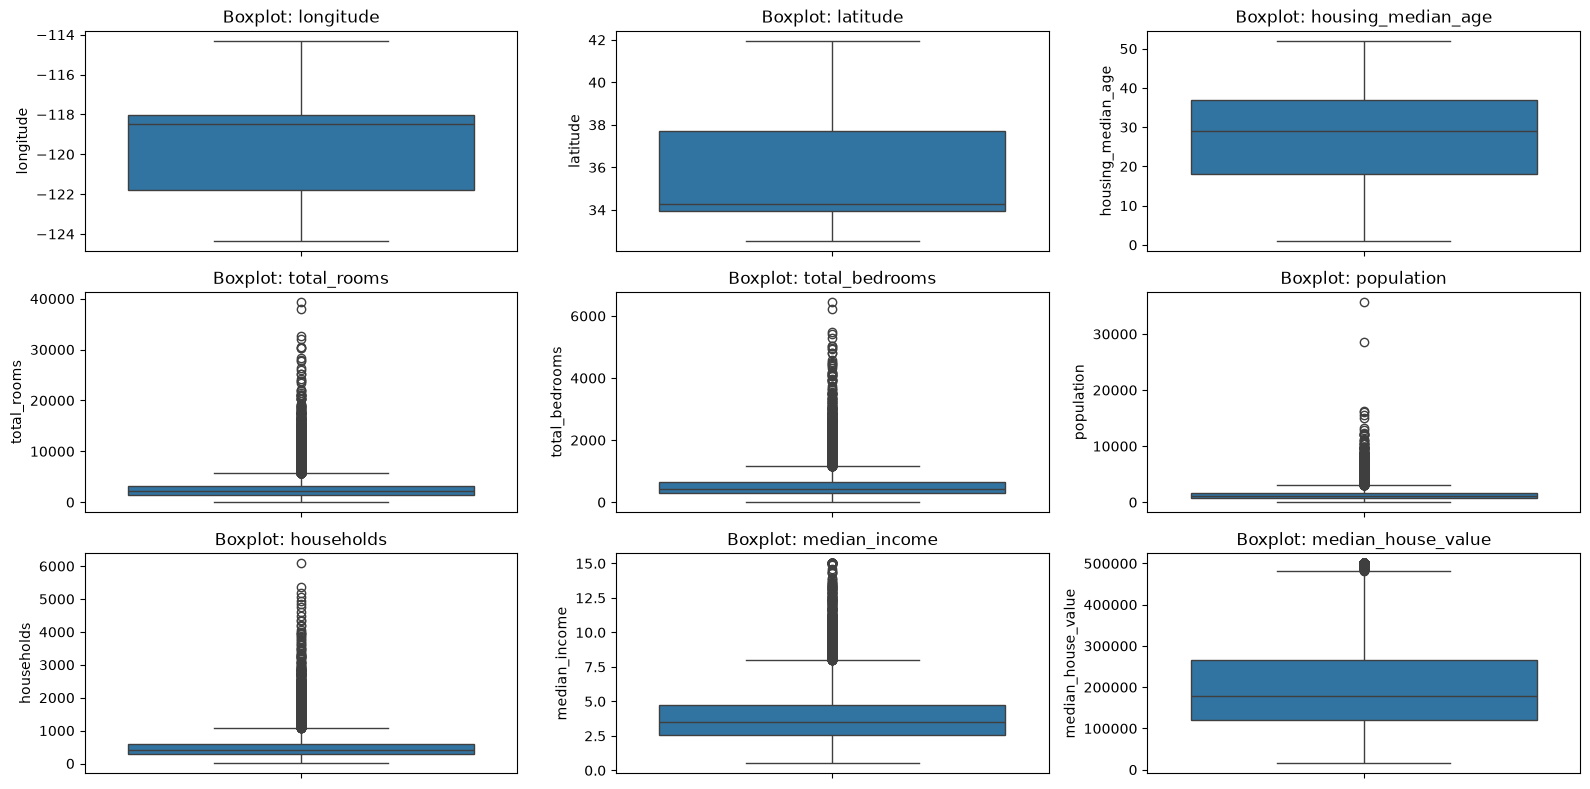

In [18]:
# lets check for outlier using boxplot because having a skewness doesn't necessary mean there is an outlier.

# Note: Each boxplot shows: Median → the middle line inside the box IQR (Interquartile Range) → the box (middle 50% of data)
# Whiskers → typical range of values. Dots outside whiskers → outliers

num_cols = housing.select_dtypes(include=['int64', 'float64']).columns # selecting all number columns


fig, axes = plt.subplots(3, 3, figsize=(16, 8))
axes = axes.flatten() # to make seperation of each plot easier

for col, ax in zip(num_cols, axes):
    sns.boxplot(housing[col], ax=ax)
    ax.set_title(f'Boxplot: {col}')

plt.tight_layout()
plt.show()

# there are outliers in the columns where we have skewness. Meaning some values are far apart from other values which can affect our model.

In [19]:
# lets check for correlation corresponding to our target value 

housing_corr = housing.corr(numeric_only=True)
print(housing_corr['median_house_value'].sort_values(ascending=False))

# the most correlated is median income meaning the target or prediction depends mostly on median income then total_rooms, housing_median_age
# minimally on households and total_bedrooms.

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


In [21]:
# based on the fact that we have skewness and outliers in median income we need to ensure there is equal distribution of 
# it on train and test so we are stratifying based on median income.

# Making a new feature out of median income because we need labels or categories and it is in numbers
housing['income_cat']= pd.cut(housing['median_income'], bins=[0., 1.5, 3., 4.5, 6., np.inf], labels=[1, 2, 3, 4, 5])

# using a library to stratify shuffle and make a well balanced 80%, 10 different train set and 20% test set

from sklearn.model_selection import StratifiedShuffleSplit

splits=[]
splitter = StratifiedShuffleSplit(
    n_splits=10, test_size=0.2, random_state=42)

for train_ind, test_ind in splitter.split(housing, housing['income_cat']): # using split to add the data we are splitting and the labels need equally
    train = housing.iloc[train_ind].copy()
    test = housing.iloc[test_ind].copy()
    splits.append((train, test)) # one bracket is for append but two means its a tuple we are appending.

# selecting the first train data
strat_train, strat_test = splits[0]

# Print the percentage distribution of each income category in the stratified training and test sets. Using normalize=True shows proportions
# instead of raw counts, allowing us to verify that stratified sampling preserved the same category ratios in both splits.
print(strat_train['income_cat'].value_counts(normalize=True).sort_index())
print(strat_test['income_cat'].value_counts(normalize=True).sort_index())

income_cat
1    0.039789
2    0.318859
3    0.350594
4    0.176296
5    0.114462
Name: proportion, dtype: float64
income_cat
1    0.039971
2    0.318798
3    0.350533
4    0.176357
5    0.114341
Name: proportion, dtype: float64


In [22]:
# Removing the income_cat since we are done stratifying and its not needed

print('Keys before dropping', strat_train.keys())
print()

strat_train, strat_test = (
    strat_train.drop('income_cat', axis=1), 
    strat_test.drop('income_cat', axis=1))
print('Keys after dropping', strat_train.keys())

Keys before dropping Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity', 'income_cat'],
      dtype='str')

Keys after dropping Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')


In [23]:
# we can also make more correlated features

housing['bedroom_ratio'] = housing['total_rooms']/housing['total_rooms']
housing['people_per_house'] = housing['population']/housing['households']
housing['rooms_per_house'] = housing['total_rooms']/housing['households']

house_corr = housing.corr(numeric_only=True)
print(house_corr['median_house_value'].sort_values(ascending=False))

# we can see room_per_house is more correlated than total_rooms

median_house_value    1.000000
median_income         0.688075
rooms_per_house       0.151948
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
people_per_house     -0.023737
population           -0.024650
longitude            -0.045967
latitude             -0.144160
bedroom_ratio              NaN
Name: median_house_value, dtype: float64


In [25]:
# Separate features and target from the stratified training set.
#We drop 'median_house_value' to create the feature matrix (housing), and store the target values separately in housing_labels.

housing = strat_train.copy()
housing = strat_train.drop('median_house_value', axis=1)
housing_labels = strat_train['median_house_value'].copy()

print(housing.keys())
print()
print(housing_labels.name)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity'],
      dtype='str')

median_house_value


In [27]:
# Building a full preprocessing pipeline:
# - Identify numeric and categorical columns
# - Split numeric features into skewed vs. non‑skewed groups
# - Apply median imputation to all numeric columns
# - Apply log1p transformation only to skewed numeric columns to reduce outliers and skewness
# - Scale all numeric features with StandardScaler
# - One‑hot encode categorical features
# - Combine all transformations using ColumnTransformer so the model receives a clean, fully processed feature matrix

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer

num_cat=housing.select_dtypes(include=['int64', 'float64']).columns
str_cat=['ocean_proximity']
skew_cols=['total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']

skewed_num = skew_cols
unskewed_num = [col for col in num_cat if col not in skew_cols]

skewed_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(np.log1p, validate=True, feature_names_out='one-to-one')),
    ('scaler', StandardScaler())
])

num_pipeline= Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

str_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

full_pipeline= ColumnTransformer([
    ('skewed', skewed_pipeline, skewed_num),
    ('num', num_pipeline, num_cat),
    ('str', str_pipeline, str_cat)
])

housing_prepared = full_pipeline.fit_transform(housing)

In [28]:
# Convert the transformed NumPy array back into a DataFrame and attach the generated feature names from the pipeline. This allows us to inspect 
# exactly which features were created (including log‑transformed columns, scaled columns, and one‑hot encoded categorical features). 
# Printing each name helps verify that the ColumnTransformer applied all steps correctly and produced the expectedfeature set.

housing_prepared_df = pd.DataFrame(housing_prepared, columns=full_pipeline.get_feature_names_out())
for name in full_pipeline.get_feature_names_out():
    print(name)

skewed__total_rooms
skewed__total_bedrooms
skewed__population
skewed__households
skewed__median_income
num__longitude
num__latitude
num__housing_median_age
num__total_rooms
num__total_bedrooms
num__population
num__households
num__median_income
str__ocean_proximity_<1H OCEAN
str__ocean_proximity_INLAND
str__ocean_proximity_ISLAND
str__ocean_proximity_NEAR BAY
str__ocean_proximity_NEAR OCEAN


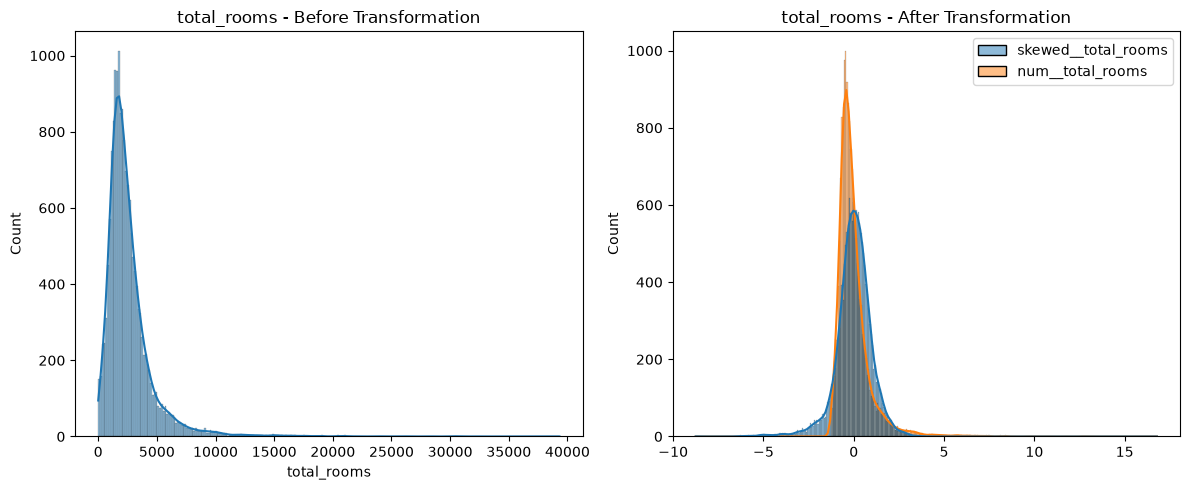

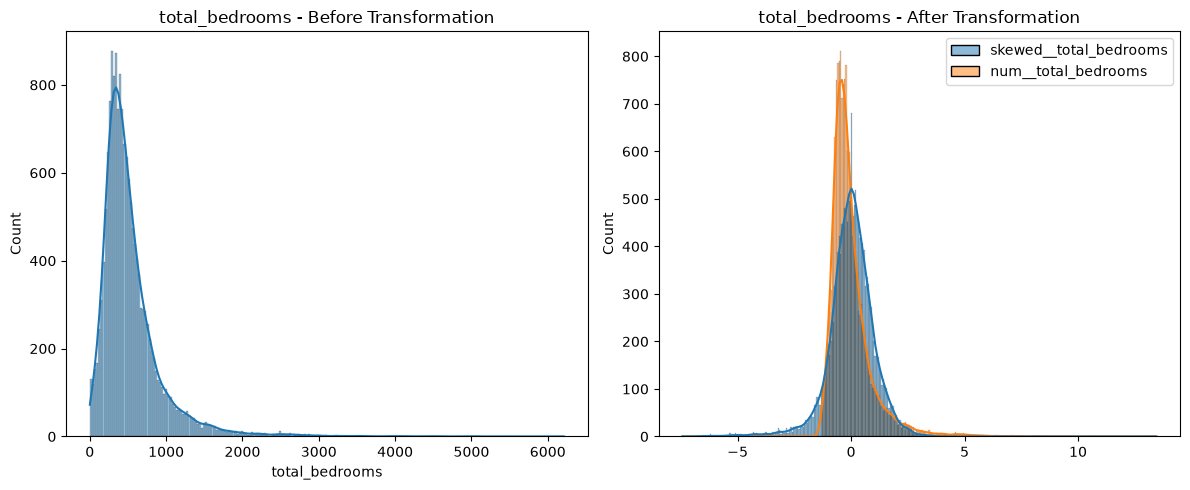

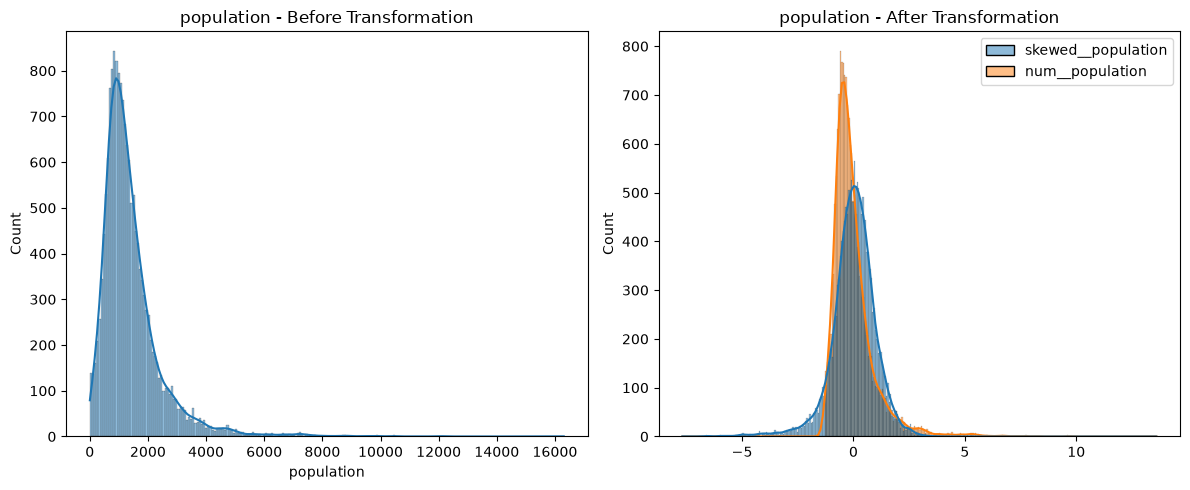

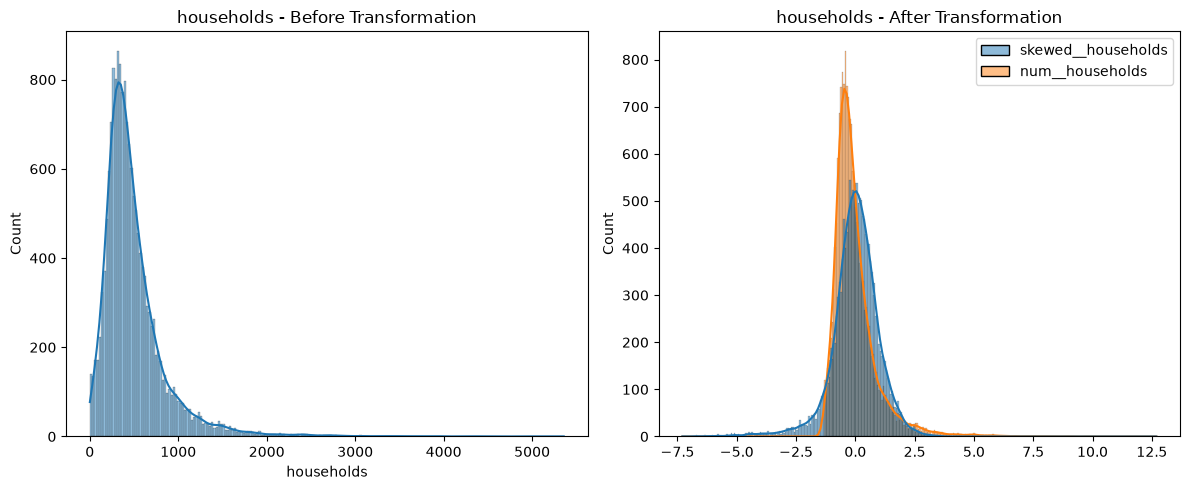

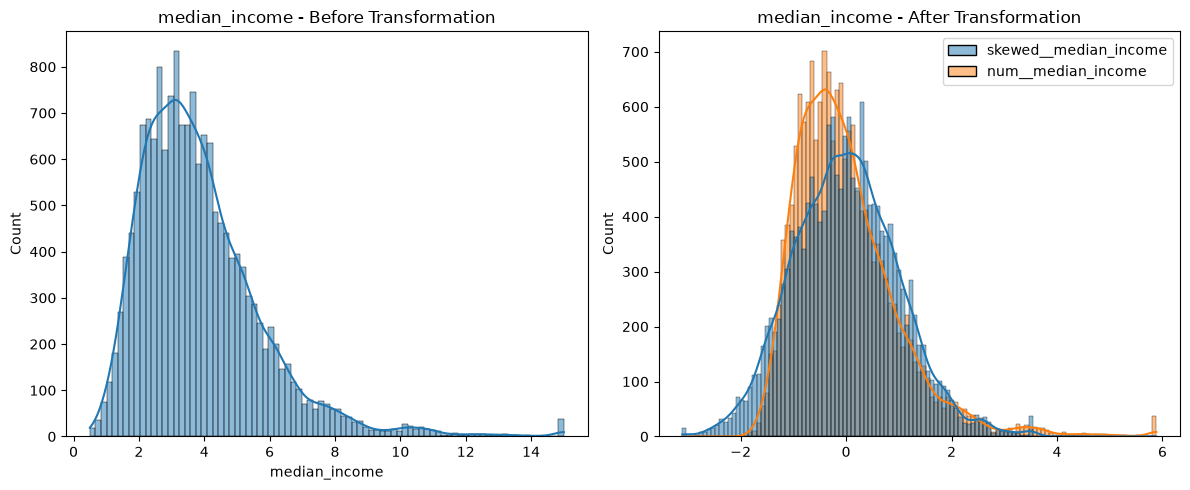

In [30]:
# visualise before and after cleaning transforming and scaling.

skewed_cols = ['total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
for col in skewed_cols:
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    sns.histplot(housing[col], kde=True)
    plt.title(f'{col} - Before Transformation')

    plt.subplot(1, 2, 2)
    transformed = housing_prepared_df.filter(like=col)
    sns.histplot(transformed, kde=True)
    plt.title(f'{col} - After Transformation')

    plt.tight_layout()
    plt.show()

In [32]:
# using linear regression
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression

lr = make_pipeline(full_pipeline, LinearRegression())
lr.fit(housing, housing_labels)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['longitude','latitude','housing_median_age',...,'households', 'median_income','ocean_proximity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('skewed', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be auto

In [33]:
housing_prediction = lr.predict(housing)
print(housing_prediction[:5].round(-2))
print(housing_labels[:5].values)

[270800. 359900. 119100. 109800. 298200.]
[458300. 483800. 101700.  96100. 361800.]


In [34]:
# make testing and labels

testing = strat_test.copy()
testing = strat_test.drop('median_house_value', axis=1)
testing_labels = strat_test['median_house_value'].copy()

In [35]:
testing_prediction = lr.predict(testing)
print(testing_prediction[:5].round(-2))
print(testing_labels[:5].values)

[386500. 244600. 339500. 274500. 260700.]
[397700. 202900. 310000. 314300. 187500.]


In [37]:
# getting the mean square error

from sklearn.metrics import mean_squared_error

mse = mean_squared_error(testing_labels, testing_prediction)
mse2 = mean_squared_error(housing_labels, housing_prediction)
print("MSE on test set:", mse)
print("MSE on train set:", mse2)

MSE on test set: 4596507978.072482
MSE on train set: 4379260424.830286


In [38]:
# printing the root mean square

rmse_test = np.sqrt(mse)
rmse_train = np.sqrt(mse2)

print("Actual RMSE on test set:", rmse_test)
print("Actual RMSE on train set:", rmse_train)

# MSE is the average squared prediction error; large values are expected because errors are squared.
# Train MSE < Test MSE indicates the model generalizes reasonably well.
# To interpret the error in real units (dollars), take the square root to obtain RMSE.

Actual RMSE on test set: 67797.55141649647
Actual RMSE on train set: 66175.98072435561


In [40]:
# making a Decision Tree Regressor

from sklearn.tree import DecisionTreeRegressor

tree = make_pipeline(full_pipeline, DecisionTreeRegressor(# add a random state))
tree.fit(housing, housing_labels)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('decisiontreeregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['longitude','latitude','housing_median_age',...,'households', 'median_income','ocean_proximity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('skewed', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be

In [43]:
# Decision Trees can perfectly memorize the training data, so RMSE on the training set becomes 0.0. This indicates severe overfitting: the model fits
# every detail of the training set but will perform poorly on unseen data.


from sklearn.metrics import root_mean_squared_error


housing_prediction = tree.predict(housing)
tree_rmse= root_mean_squared_error(housing_labels, housing_prediction)
print(tree_rmse)

# A model with RMSE = 0.0 on training data is: too flexible, too deep, overfitted memorizing instead of learning
# therefore we have to use another model

0.0
